<a href="https://colab.research.google.com/github/LNDOTIS/FlyRank-AI-Internship---Machine-Learning/blob/main/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup and load warehouse

### Research question

Can historical search-performance and content-lifecycle signals identify pages
that are likely to experience a significant decline in organic search impressions
over the next 30 days?


---


### Prediction setup

**Feature window**:
`2026-03-01 to 2026-03-31`

**Prediction point**:
`2026-04-01`

**Target window**:
`2026-04-01 to 2026-04-30`

**Unit of analysis**:
one content page for one client at one prediction point.

**Target**:
`is_declining = 1` when impressions in the future 30-day window are more than
20% lower than impressions in the previous 30-day feature window.

The model must use only information available at the prediction point.

The **Week-4 baseline** and the **learned model** are evaluated on the same held-out
client groups and using the same ranking metrics.

In [2]:
%pip -q install duckdb huggingface_hub scikit-learn pandas numpy matplotlib

- `duckdb` → query the large Parquet warehouse
- `huggingface_hub` → access the gated FlyRank warehouse
- `pandas / numpy` → manipulate the resulting feature table
- `scikit-learn` → train and evaluate the models
- `matplotlib` → optional plots

In [3]:
import os
import getpass
import duckdb
import pandas as pd
import numpy as np

HF_TOKEN = (os.environ.get("HF_TOKEN") or getpass.getpass("Paste your Hugging Face READ token (hf_...): "))

con = duckdb.connect()

con.execute(f"CREATE OR REPLACE SECRET hf " f"(TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients":                  f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content":                  f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily":                   f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d":               f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

Paste your Hugging Face READ token (hf_...): ··········


In [4]:
warehouse_check = con.sql(
    f"""
    SELECT
        COUNT(*) AS row_count,
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date
    FROM {TABLES["fact_daily"]}
    """
).df()

display(warehouse_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,row_count,min_date,max_date
0,78835655,2025-01-27,2026-06-30


In [5]:
grain_check = con.sql(
    f"""
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        COUNT(*) AS n
    FROM {TABLES["fact_daily"]}
    WHERE report_date >= DATE '2026-03-01'
      AND report_date < DATE '2026-04-01'
    GROUP BY
        report_date,
        client_hash_id,
        content_hash_id
    HAVING COUNT(*) > 1
    LIMIT 10
    """
).df()

display(grain_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,report_date,client_hash_id,content_hash_id,n


## Prediction Windows

In [6]:
FEATURE_START = "2026-03-01"
FEATURE_END   = "2026-04-01"

TARGET_START = "2026-04-01"
TARGET_END   = "2026-05-01"

print("Feature window:", FEATURE_START, "to", FEATURE_END)
print("Target window: ", TARGET_START, "to", TARGET_END)

Feature window: 2026-03-01 to 2026-04-01
Target window:  2026-04-01 to 2026-05-01


```text
                  Prediction
                    point
                      │
                      ▼
March 1 ──────────────┼────────────── April 30
           FEATURES   │    TARGET
           known      │    unknown

## Build the feature window

Five features that were established earlier:

- `imp_prev30`
- `clk_prev30`
- `avg_position_prev30`
- `days_with_impressions`
- `content_age_days`

In [7]:
features = con.sql(
    f"""
    WITH feature_window AS (

        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS imp_prev30,
            SUM(gsc_clicks) AS clk_prev30,
            AVG(gsc_avg_position) AS avg_position_prev30,
            COUNT(*) FILTER (WHERE gsc_impressions > 0) AS days_with_impressions
        FROM {TABLES["fact_daily"]}
        WHERE report_date >= DATE '{FEATURE_START}' AND report_date < DATE '{FEATURE_END}' AND gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    )

    SELECT
        f.client_hash_id,
        f.content_hash_id,
        f.imp_prev30,
        f.clk_prev30,
        f.avg_position_prev30,
        f.days_with_impressions,
        DATE_DIFF('day', c.content_created_date, DATE '{TARGET_START}') AS content_age_days
    FROM feature_window f
    LEFT JOIN {TABLES["dim_content"]} c
        ON f.client_hash_id = c.client_hash_id AND f.content_hash_id = c.content_hash_id
    WHERE f.imp_prev30 >= 100
    """
).df()

print("Feature rows:", f"{len(features):,}")
display(features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature rows: 101,441


,client_hash_id,content_hash_id,imp_prev30,clk_prev30,avg_position_prev30,days_with_impressions,content_age_days
0,client_0797ff3a1fc9a6a5,content_04c67f3541177192,331.0,2.0,14.129210,31,176
1,client_0797ff3a1fc9a6a5,content_0f30e04e709c7b5d,145.0,0.0,8.470926,30,176
2,client_0797ff3a1fc9a6a5,content_1207efddce873942,461.0,0.0,14.859827,31,176
3,client_0797ff3a1fc9a6a5,content_167472cd0802a8f3,232.0,0.0,12.297523,29,176
4,client_0797ff3a1fc9a6a5,content_27f8100281413b37,464.0,0.0,9.554793,18,176


## Feature availability

The five model features are historical or lifecycle variables.

- `imp_prev30`:
  GSC impressions observed during March 2026.

- `clk_prev30`:
  GSC clicks observed during March 2026.

- `avg_position_prev30`:
  Average GSC position observed during March 2026.

- `days_with_impressions`:
  Number of March days on which the page had positive GSC impressions.

- `content_age_days`:
  Age of the content at the prediction point.

None of these variables uses April 2026 performance. The client and content hash IDs are retained only for grouping, joining,
validation, and error analysis. They are not model features.

## Build the future outcome

Now we deliberately access April. This is okay because April is used to create the label, not the features.

In [8]:
future_outcomes = con.sql(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS imp_next30,
        SUM(gsc_clicks) AS clk_next30
    FROM {TABLES["fact_daily"]}
    WHERE report_date >= DATE '{TARGET_START}' AND report_date < DATE '{TARGET_END}' AND gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
    """
).df()

print("Future outcome rows:", f"{len(future_outcomes):,}")
display(future_outcomes.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Future outcome rows: 194,760


,client_hash_id,content_hash_id,imp_next30,clk_next30
0,client_62f4a7e64f5e0096,content_76c1f31e2b38f054,249.0,1.0
1,client_62f4a7e64f5e0096,content_ffc5ab4b34aab1f8,281.0,0.0
2,client_62f4a7e64f5e0096,content_9739856fc83dc1ca,722.0,0.0
3,client_62f4a7e64f5e0096,content_3d1dc691a3502105,3068.0,1.0
4,client_62f4a7e64f5e0096,content_9d28af4f99c5e67b,3896.0,3.0


## Join features and future outcomes


In [9]:
data = features.merge(future_outcomes, on=["client_hash_id", "content_hash_id"], how="inner")

print("Final modeling rows:", f"{len(data):,}")
display(data.head())

Final modeling rows: 100,893


,client_hash_id,content_hash_id,imp_prev30,clk_prev30,avg_position_prev30,days_with_impressions,content_age_days,imp_next30,clk_next30
0,client_0797ff3a1fc9a6a5,content_04c67f3541177192,331.0,2.0,14.129210,31,176,561.0,3.0
1,client_0797ff3a1fc9a6a5,content_0f30e04e709c7b5d,145.0,0.0,8.470926,30,176,23.0,0.0
2,client_0797ff3a1fc9a6a5,content_1207efddce873942,461.0,0.0,14.859827,31,176,964.0,0.0
3,client_0797ff3a1fc9a6a5,content_167472cd0802a8f3,232.0,0.0,12.297523,29,176,248.0,0.0
4,client_0797ff3a1fc9a6a5,content_27f8100281413b37,464.0,0.0,9.554793,18,176,1138.0,0.0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## Create the target

In [10]:
data["impression_change_pct"] = (data["imp_next30"] - data["imp_prev30"]) / data["imp_prev30"]
data["is_declining"] = (data["impression_change_pct"] < -0.20).astype(int)

print(data["is_declining"].value_counts().rename({0: "not_declining", 1: "declining"}))
print("\nDecline rate:")
print(round(data["is_declining"].mean(), 4))

is_declining
declining        51944
not_declining    48949
Name: count, dtype: int64

Decline rate:
0.5148


In [11]:
target_summary = pd.DataFrame({
    "n": data["is_declining"].value_counts(),
    "rate": data["is_declining"].value_counts(normalize=True)
})

target_summary.index = ["declining" if x == 1 else "not_declining" for x in target_summary.index]
target_summary["rate"] = (target_summary["rate"] * 100).round(2)

display(target_summary)

,n,rate
declining,51944,51.48
not_declining,48949,48.52


## Define the model features


In [12]:
feature_cols = [
    "imp_prev30",
    "clk_prev30",
    "avg_position_prev30",
    "days_with_impressions",
    "content_age_days"
]

print("Model features:")
for col in feature_cols:
    print("-", col)

Model features:
- imp_prev30
- clk_prev30
- avg_position_prev30
- days_with_impressions
- content_age_days


In [13]:
missing_check = data[feature_cols].isna().sum().to_frame("missing")
missing_check["missing_pct"] = (missing_check["missing"] / len(data) * 100).round(2)

display(missing_check)

,missing,missing_pct
imp_prev30,0,0.0
clk_prev30,0,0.0
avg_position_prev30,0,0.0
days_with_impressions,0,0.0
content_age_days,0,0.0


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

The task is **binary prediction**:

>"Will this page experience a greater-than-20% impression decline
in the next 30 days?"

I start with **Logistic Regression** because it is simple, reproducible,
and gives a useful benchmark for a `yes/no` prediction problem. I then use **Random Forest** as a stronger nonlinear model.

The Random Forest is useful because relationships between historical
visibility, clicks, ranking position, and future decline may not be linear.

The goal is not to maximize complexity. The goal is to determine whether
a learned model can improve the **Week-4** transparent rule on the same
held-out pages.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

### Important: client-grouped split

Suppose:
```text
Client A:  
     page 1 → train
     page 2 → test
     page 3 → train
     page 4 → test
```
The model sees many pages from Client A during training and is then tested on another page from the same client. That can make the result look better than it really is.

Our contract already identified `client_hash_id` as important for grouped validation. We will therefore hold out entire clients.

In [14]:
from sklearn.model_selection import GroupShuffleSplit

model_data = data.dropna(subset=["is_declining"]).copy()

groups = model_data["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

train_idx, test_idx = next(gss.split(model_data, model_data["is_declining"], groups=groups))

train_data = model_data.iloc[train_idx].copy()
test_data = model_data.iloc[test_idx].copy()

print("Train rows:", f"{len(train_data):,}")
print("Test rows: ", f"{len(test_data):,}")

print()
print("Train clients:", train_data["client_hash_id"].nunique())
print("Test clients:", test_data["client_hash_id"].nunique())

Train rows: 84,384
Test rows:  16,509

Train clients: 32
Test clients: 11


In [15]:
train_clients = set(train_data["client_hash_id"])
test_clients = set(test_data["client_hash_id"])

print("Overlapping clients:", len(train_clients & test_clients))
print("PASS: no client appears in both train and test.")

Overlapping clients: 0
PASS: no client appears in both train and test.


Thus, this is the group-level holdout that answers a more practical question:

> If I encounter a new client that the model has never seen before, can the model make good predictions for that client's pages?

### Compare target rates in train/test

They don't need to be identical. But they should be reasonably comparable.

Because we're grouping by client, the distribution can differ slightly depending on which clients land in the test set.

In [16]:
print("Train decline rate:", round(train_data["is_declining"].mean(), 3))
print("Test decline rate:", round(test_data["is_declining"].mean(), 3))

Train decline rate: 0.537
Test decline rate: 0.402


### Build X and y

In [17]:
X_train = train_data[feature_cols]
y_train = train_data["is_declining"]

X_test = test_data[feature_cols]
y_test = test_data["is_declining"]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (84384, 5)
X_test:  (16509, 5)
y_train: (84384,)
y_test:  (16509,)


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

### Build the Logistic Regression model

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                                 ("scaler", StandardScaler()),
                                 ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [19]:
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]
logistic_pred = (logistic_prob >= 0.5).astype(int)

### Build the Random Forest model

In [20]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
               steps=[("imputer", SimpleImputer(strategy="median")),
                      ("model", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, class_weight="balanced", random_state=42, n_jobs=-1))])

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=20, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [21]:
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)

### Evaluation functions

In [22]:
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

def precision_at_k(scores, labels, k):
    scores = np.asarray(scores)
    labels = np.asarray(labels)

    order = np.argsort(-scores)
    top_k = labels[order[:k]]

    return top_k.mean()

### Week 4 Baseline

The baseline is a transparent rule:

A page receives a high review score when it is both:

>1. visible enough to have meaningful historical search exposure, and
>2. stale enough to potentially need attention.

Among qualifying pages, higher historical impressions receive a higher score. This is deliberately simple and contains no fitted parameters.

The baseline is evaluated on the exact same held-out test pages as the models.

In [25]:
BASELINE_VISIBLE = 500
BASELINE_STALE = 180

baseline_test = test_data.copy()

baseline_test["stale"] = (baseline_test["content_age_days"] >= BASELINE_STALE).astype(int)
baseline_test["visible"] = (baseline_test["imp_prev30"] >= BASELINE_VISIBLE).astype(int)

baseline_test["baseline_score"] = baseline_test["stale"] * baseline_test["visible"] * baseline_test["imp_prev30"]

baseline_test["baseline_reason"] = np.select(
    [(baseline_test["stale"].eq(1) & baseline_test["visible"].eq(1)), baseline_test["stale"].eq(1), baseline_test["visible"].eq(1)],
    ["stale_and_visible", "stale_only", "visible_only"],
    default="neither")

display(
    baseline_test[
        [
            "client_hash_id",
            "content_hash_id",
            "imp_prev30",
            "content_age_days",
            "baseline_score",
            "baseline_reason",
            "is_declining"
        ]
    ].sort_values("baseline_score", ascending=False).head(10)
)

,client_hash_id,content_hash_id,imp_prev30,content_age_days,baseline_score,baseline_reason,is_declining
87168,client_e547b89c05043229,content_eadb33b5df496f4a,617124.0,376,617124.0,stale_and_visible,0
87204,client_e547b89c05043229,content_ec2e0346994fb5a5,245276.0,435,245276.0,stale_and_visible,1
79848,client_e547b89c05043229,content_0e03de7680314cd5,221310.0,376,221310.0,stale_and_visible,0
84122,client_e547b89c05043229,content_8d7d99f109e19aa2,203497.0,376,203497.0,stale_and_visible,0
82035,client_e547b89c05043229,content_4ffe18112a5642e3,186983.0,376,186983.0,stale_and_visible,0
82181,client_e547b89c05043229,content_545bb6cc7081ded3,122905.0,376,122905.0,stale_and_visible,0
83362,client_e547b89c05043229,content_77276ad7a26f4905,116707.0,468,116707.0,stale_and_visible,0
87621,client_e547b89c05043229,content_f86f77b3ebdc05ee,105420.0,468,105420.0,stale_and_visible,0
80487,client_e547b89c05043229,content_21309e9a83c83653,103187.0,376,103187.0,stale_and_visible,0
84415,client_e547b89c05043229,content_963de14b1f58978f,97312.0,468,97312.0,stale_and_visible,0


In [26]:
y_test_array = y_test.to_numpy()

baseline_scores = baseline_test["baseline_score"].to_numpy()

for k in [20, 50, 100]:
    score = precision_at_k(baseline_scores, y_test_array, k)
    print(f"Week-4 baseline Precision@{k}: {score:.3f}")

Week-4 baseline Precision@20: 0.350
Week-4 baseline Precision@50: 0.380
Week-4 baseline Precision@100: 0.360


In [30]:
results = []

for model_name, scores, predictions in [("Logistic Regression", logistic_prob, logistic_pred), ("Random Forest", rf_prob, rf_pred),
                                        ("Baseline", baseline_scores, None)]:

    row = {"model": model_name,
           "precision@20": precision_at_k(scores, y_test_array, 20),
           "precision@50": precision_at_k(scores, y_test_array, 50),
           "precision@100": precision_at_k(scores, y_test_array, 100)}

    if predictions is not None:
        row["ROC-AUC"] = roc_auc_score(y_test, scores)
        row["precision"] = precision_score(y_test, predictions)
        row["recall"] = recall_score(y_test, predictions)
        row["F1"] = f1_score(y_test, predictions)
    else:
        row["ROC-AUC"] = np.nan
        row["precision"] = np.nan
        row["recall"] = np.nan
        row["F1"] = np.nan

    results.append(row)

comparison = pd.DataFrame(results)

display(comparison.round(3))

,model,precision@20,precision@50,precision@100,ROC-AUC,precision,recall,F1
0,Logistic Regression,0.60,0.46,0.54,0.62,0.472,0.656,0.549
1,Random Forest,0.45,0.44,0.43,0.58,0.436,0.604,0.506
2,Baseline,0.35,0.38,0.36,NaN,NaN,NaN,NaN


In [31]:
base_rate = y_test.mean()

print(f"Test-set decline base rate: {base_rate:.3f}")

comparison["base_rate"] = base_rate

display(comparison.round(3))

Test-set decline base rate: 0.402


,model,precision@20,precision@50,precision@100,ROC-AUC,precision,recall,F1,base_rate
0,Logistic Regression,0.60,0.46,0.54,0.62,0.472,0.656,0.549,0.402
1,Random Forest,0.45,0.44,0.43,0.58,0.436,0.604,0.506,0.402
2,Baseline,0.35,0.38,0.36,NaN,NaN,NaN,NaN,0.402


Logistic Regression performed best on the ranking metrics. Its Precision@20 was 0.60, compared with 0.35 for the baseline. This means that approximately 60% of the top 20 pages ranked by the model were actually declining, compared with 35% for the baseline.

The model also outperformed the baseline at Precision@50 and Precision@100. The largest improvement was at Precision@20, which is useful because a content team has limited review capacity and may only inspect the highest-priority pages.

The base rate was 0.402, meaning that approximately 40.2% of pages in the evaluation set were declining. Therefore, the model's Precision@20 of 0.60 is above both the base rate and the Week-4 baseline.

Random Forest did not improve on Logistic Regression in this experiment. Its Precision@20 was 0.45 and ROC-AUC was 0.58, compared with 0.60 and 0.62 for Logistic Regression. This suggests that the additional complexity of the Random Forest did not provide additional predictive value for this feature set and validation split.

Overall, the results support Logistic Regression as the preferred first model for this lane. The result should be interpreted as decision-support rather than as a highly accurate prediction system.

### Feature Importance

In [39]:
lg_estimator = logistic_model.named_steps["model"]
feature_importance_2 = pd.DataFrame({"feature": feature_cols, "importance": lg_estimator.coef_[0]}).sort_values("importance",ascending=False)

display(feature_importance_2)

,feature,importance
3,days_with_impressions,0.443663
0,imp_prev30,0.128512
4,content_age_days,-0.034751
2,avg_position_prev30,-0.048132
1,clk_prev30,-0.683320


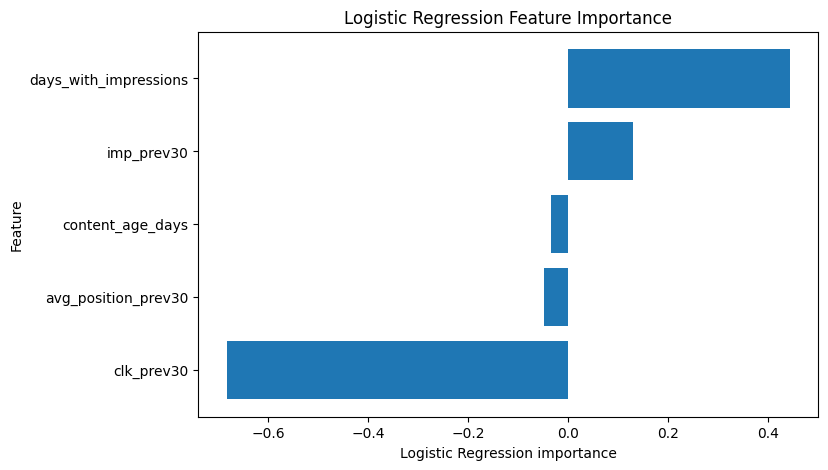

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance_2["feature"],
    feature_importance_2["importance"]
)

plt.xlabel("Logistic Regression importance")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Importance")

plt.gca().invert_yaxis()

plt.show()

The logistic regression coefficients show that `days_with_impressions` is the strongest positive predictor of future decline, with `imp_prev30` also having a positive coefficient. A positive coefficient means that, holding the other features constant, higher values of that feature are associated with a higher predicted probability of the page being classified as declining. In contrast, `clk_prev30` has a large negative coefficient, making it the strongest negative predictor in the model. This means that pages with more historical clicks tend to have a lower predicted probability of decline, all else being equal. The negative sign does not mean that clicks are “bad”; rather, it indicates an inverse relationship between historical clicks and the decline label. `content_age_days` and `avg_position_prev30` have coefficients close to zero, suggesting that they contribute relatively little to the model's decision compared with the other features. Overall, the model is relying most strongly on historical engagement and visibility signals, with `days_with_impressions` pushing predictions toward decline and `clk_prev30` pushing them away from decline.

In [43]:
comparison_test = test_data[
    [
        "client_hash_id",
        "content_hash_id",
        "imp_prev30",
        "clk_prev30",
        "avg_position_prev30",
        "days_with_impressions",
        "content_age_days",
        "is_declining"
    ]
].copy()

comparison_test["baseline_score"] = baseline_test["baseline_score"].values
comparison_test["rf_score"] = rf_prob
comparison_test["logistic_score"] = logistic_prob

display(comparison_test.sort_values("rf_score", ascending=False).head(20))

,client_hash_id,content_hash_id,imp_prev30,clk_prev30,avg_position_prev30,days_with_impressions,content_age_days,is_declining,baseline_score,rf_score,logistic_score
85547,client_e547b89c05043229,content_b888c64c308ad61f,783.0,0.0,7.217057,29,476,0,783.0,0.908269,0.517937
82367,client_e547b89c05043229,content_592579adbd300382,939.0,0.0,6.686595,29,476,0,939.0,0.905874,0.519117
86910,client_e547b89c05043229,content_e36ebbe98f9f56ba,445.0,0.0,7.124607,29,476,0,0.0,0.905268,0.516438
81004,client_e547b89c05043229,content_30ee715a863485a3,1506.0,0.0,6.783731,29,476,1,1506.0,0.905236,0.521679
80817,client_e547b89c05043229,content_2b8311a93f08e99c,783.0,0.0,7.042547,29,435,1,783.0,0.904761,0.521117
80331,client_e547b89c05043229,content_1c6380e64bc639bd,507.0,0.0,6.762152,29,435,0,507.0,0.903251,0.520069
85362,client_e547b89c05043229,content_b1ba8af0b5baa5e0,383.0,0.0,7.235669,29,435,0,0.0,0.902947,0.519087
86179,client_e547b89c05043229,content_cc07d31c28e81d0a,1823.0,0.0,7.696801,29,476,1,1823.0,0.902510,0.522381
80780,client_e547b89c05043229,content_2a7cb7ad6dd67268,376.0,0.0,7.001910,29,476,0,0.0,0.902198,0.516221
84936,client_e547b89c05043229,content_a4f48305800deb8a,927.0,0.0,7.373446,29,476,0,927.0,0.901581,0.518476


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [45]:
error_analysis = test_data[
    [
        "client_hash_id",
        "content_hash_id",
        "imp_prev30",
        "clk_prev30",
        "avg_position_prev30",
        "days_with_impressions",
        "content_age_days",
        "imp_next30",
        "is_declining"
    ]
].copy()

error_analysis["logistic_probability"] = logistic_prob
error_analysis["logistic_prediction"] = logistic_pred

error_analysis["error_type"] = np.select(
    [((error_analysis["logistic_prediction"] == 1) & (error_analysis["is_declining"] == 0)),
     ((error_analysis["logistic_prediction"] == 0) & (error_analysis["is_declining"] == 1))],
    ["false_positive", "false_negative"],
    default="correct")

display(error_analysis["error_type"].value_counts())

,count
error_type,
correct,9355
false_positive,4874
false_negative,2280


In [47]:
false_positives = error_analysis[error_analysis["error_type"] == "false_positive"].sort_values("logistic_probability",ascending=False)
display(false_positives.head(3))

,client_hash_id,content_hash_id,imp_prev30,clk_prev30,avg_position_prev30,days_with_impressions,content_age_days,imp_next30,is_declining,logistic_probability,logistic_prediction,error_type
88634,client_1a730cb2640a1abf,content_39e19a3ec2d95f9d,42185.0,4.0,9.099972,30,70,186872.0,0,0.723298,1,false_positive
86270,client_e547b89c05043229,content_cf2264753938463b,46938.0,11.0,4.111066,29,435,53785.0,0,0.670898,1,false_positive
80751,client_e547b89c05043229,content_29caed0f85034d5c,41655.0,13.0,5.063695,29,257,62849.0,0,0.649860,1,false_positive


In [48]:
false_negatives = error_analysis[error_analysis["error_type"] == "false_negative"].sort_values("logistic_probability",ascending=False)
display(false_negatives.head(3))

,client_hash_id,content_hash_id,imp_prev30,clk_prev30,avg_position_prev30,days_with_impressions,content_age_days,imp_next30,is_declining,logistic_probability,logistic_prediction,error_type
83656,client_e547b89c05043229,content_7ff6114335cb1d4a,650.0,3.0,12.982159,29,418,441.0,1,0.499997,0,false_negative
81125,client_e547b89c05043229,content_34c678c10ae82ba3,1267.0,6.0,5.198725,29,321,862.0,1,0.499994,0,false_negative
86229,client_e547b89c05043229,content_cd6b6de0287a3819,191.0,0.0,12.049844,28,321,115.0,1,0.499926,0,false_negative


This suggests that historical page-level signals do not completely explain
future search-performance changes. External factors, demand changes,
competition, and other unobserved signals may contribute to the outcome.

The error review is therefore consistent with using the model as
decision-support rather than as a definitive explanation of why a page
declines.

In [50]:
error_analysis["visibility_bucket"] = pd.qcut(error_analysis["imp_prev30"], q=5, duplicates="drop")

error_by_visibility = (error_analysis.groupby("visibility_bucket", observed=True)
    .agg(
        n=("is_declining", "size"),
        decline_rate=("is_declining", "mean"),
        mean_predicted_risk=("logistic_probability", "mean"),
        error_rate=("logistic_prediction", lambda x: np.mean(x != error_analysis.loc[x.index,"is_declining"])))
    .reset_index())

error_by_visibility["decline_rate"] *= 100
error_by_visibility["error_rate"] *= 100

display(error_by_visibility.round(2))

,visibility_bucket,n,decline_rate,mean_predicted_risk,error_rate
0,"(99.999, 227.0]",3303,48.50,0.43,41.66
1,"(227.0, 461.0]",3302,44.52,0.47,41.64
2,"(461.0, 909.0]",3302,41.10,0.49,47.46
3,"(909.0, 2080.4]",3300,36.61,0.49,46.18
4,"(2080.4, 617124.0]",3302,30.13,0.44,39.73


Therefore, the model struggles with **medium-visibility pages**.

# Final interpretation

The test-set decline base rate was **0.402**.

The Week-4 transparent baseline achieved:

- Precision@20 = **0.35**
- Precision@50 = **0.38**
- Precision@100 = **0.36**

Logistic Regression achieved:

- Precision@20 = **0.60**
- Precision@50 = **0.46**
- Precision@100 = **0.54**
- ROC-AUC = **0.62**

Random Forest achieved:

- Precision@20 = **0.45**
- Precision@50 = **0.44**
- Precision@100 = **0.43**
- ROC-AUC = **0.58**

The strongest method was **Logistic Regression**.

The result should be interpreted as directional decision-support evidence.
A stronger score does not establish causality and does not prove that the
model will perform identically for future clients or time periods.

The comparison is useful because the learned models were evaluated on the
same held-out clients and the same target definition as the Week-4 baseline.

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.